<a href="https://colab.research.google.com/github/keerthanashajip-spec/NorthStar-Data-Analytics/blob/main/notebooks/NorthStar_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar SQL and R Analytics

This notebook focuses on analysing structured operational data using SQL within R.
The objective is to identify inefficiencies in NorthStar’s legacy relational systems.

This builds on the Python data processing stage and helps highlight operational issues
such as delivery failures, cost inefficiencies, and customer complaints.

In [27]:
list.files()

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "sample_data"         "vehicles.csv"

In [28]:
install.packages("sqldf")
library(sqldf)
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [29]:
deliveries <- read.csv("deliveries.csv")
orders <- read.csv("orders.csv")
customers <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
complaints <- read.csv("complaints.csv")
hubs <- read.csv("hubs.csv")

print("All datasets loaded successfully")

[1] "All datasets loaded successfully"


In [30]:
#  DATA VERIFICATION
cat("Deliveries rows:", nrow(deliveries), "\n")
cat("Orders rows:", nrow(orders), "\n")
cat("Customers rows:", nrow(customers), "\n")
cat("Drivers rows:", nrow(drivers), "\n")
cat("Complaints rows:", nrow(complaints), "\n")

dim(deliveries)
head(deliveries)

Deliveries rows: 950 
Orders rows: 1250 
Customers rows: 650 
Drivers rows: 170 
Complaints rows: 320 


[1] 950  13

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


In [31]:
# DATA CLEANING (R SIDE)
orders$pickup_zone  <- tools::toTitleCase(tolower(trimws(orders$pickup_zone)))
orders$dropoff_zone <- tools::toTitleCase(tolower(trimws(orders$dropoff_zone)))
customers$home_zone <- tools::toTitleCase(tolower(trimws(customers$home_zone)))
drivers$base_zone   <- tools::toTitleCase(tolower(trimws(drivers$base_zone)))

cat("Zone names cleaned in R\n")

Zone names cleaned in R



# SQL ANALYSIS SECTION


In [32]:
result1 <- sqldf("
SELECT delivery_status, COUNT(*) AS total
FROM deliveries
GROUP BY delivery_status
")

print(result1)

cat("Insight: Shows proportion of failed vs successful deliveries\n")

  delivery_status total
1         Delayed   202
2          Failed   132
3          OnTime   616
Insight: Shows proportion of failed vs successful deliveries


In [33]:
result2 <- sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count,
       ROUND(AVG(fuel_or_charge_cost),2) AS avg_cost,
       ROUND(AVG(customer_rating_post_delivery),2) AS avg_rating
FROM deliveries
GROUP BY hub_id
ORDER BY failed_count DESC
")

print(result2)
cat("Insight: Identifies worst performing hubs\n")

  hub_id total_deliveries failed_count avg_cost avg_rating
1    H08              128           26    11.71       3.88
2    H05              115           23    13.69       3.67
3    H01              136           17    12.76       3.84
4    H04              127           16    13.17       3.92
5    H06              104           15    13.32       3.88
6    H07              115           14    12.92       3.88
7    H03              119           11    12.74       3.90
8    H02              106           10    12.57       3.95
Insight: Identifies worst performing hubs


In [34]:
result3 <- sqldf("
  SELECT delivery_status, AVG(fuel_or_charge_cost) AS avg_cost
  FROM deliveries
  GROUP BY delivery_status
")

print(result3)

  delivery_status avg_cost
1         Delayed 13.13871
2          Failed 13.14795
3          OnTime 12.67805


In [35]:
result4 <- sqldf("
  SELECT c.customer_id, COUNT(o.order_id) AS total_orders
  FROM customers c
  JOIN orders o ON c.customer_id = o.customer_id
  GROUP BY c.customer_id
  ORDER BY total_orders DESC
")

print(result4)

    customer_id total_orders
1         C0343            7
2         C0622            6
3         C0599            6
4         C0545            6
5         C0478            6
6         C0467            6
7         C0372            6
8         C0335            6
9         C0023            6
10        C0533            5
11        C0529            5
12        C0506            5
13        C0476            5
14        C0412            5
15        C0399            5
16        C0361            5
17        C0257            5
18        C0246            5
19        C0243            5
20        C0242            5
21        C0226            5
22        C0153            5
23        C0032            5
24        C0013            5
25        C0649            4
26        C0621            4
27        C0618            4
28        C0597            4
29        C0595            4
30        C0588            4
31        C0581            4
32        C0575            4
33        C0574            4
34        C057

In [36]:
result5 <- sqldf("
  SELECT d.hub_id, COUNT(c.complaint_id) AS complaint_count
  FROM deliveries d
  LEFT JOIN complaints c ON d.order_id = c.order_id
  GROUP BY d.hub_id
  ORDER BY complaint_count DESC
")

print(result5)
cat("Insight: Hubs with more complaints are problematic\n")

  hub_id complaint_count
1    H08              35
2    H07              33
3    H03              33
4    H01              32
5    H05              30
6    H04              28
7    H06              23
8    H02              18
Insight: Hubs with more complaints are problematic


In [37]:
result6 <- sqldf("
  SELECT delivery_status, AVG(manual_route_override_count) AS avg_override
  FROM deliveries
  GROUP BY delivery_status
")

print(result6)
cat("Insight: Higher overrides = poor route planning\n")

  delivery_status avg_override
1         Delayed    1.0742574
2          Failed    1.0378788
3          OnTime    0.9204545
Insight: Higher overrides = poor route planning


In [38]:
result7 <- sqldf("
  SELECT order_id, route_distance_km, fuel_or_charge_cost
  FROM deliveries
  WHERE fuel_or_charge_cost > 50
")

head(result7)

order_id,route_distance_km,fuel_or_charge_cost
<chr>,<dbl>,<dbl>


In [51]:
# SQL INSERT

new_delivery <- data.frame(
  delivery_id = "DL99999",
  order_id = "O99999",
  driver_id = "D001",
  vehicle_id = "V001",
  hub_id = "H01",
  dispatch_time = "2025-01-01 09:00",
  delivery_completed_at = "2025-01-01 10:00",
  delivery_status = "OnTime",
  route_distance_km = 12.5,
  manual_route_override_count = 0,
  proof_of_completion_missing = 0,
  customer_rating_post_delivery = 4.5,
  fuel_or_charge_cost = 9.99
)

deliveries_updated <- rbind(deliveries, new_delivery)

cat("Record inserted\n")

Record inserted


In [52]:
# Verify INSERT
verify_insert <- sqldf("
  SELECT * FROM deliveries_updated
  WHERE delivery_id = 'DL99999'
")
print(verify_insert)

  delivery_id order_id driver_id vehicle_id hub_id    dispatch_time
1     DL99999   O99999      D001       V001    H01 2025-01-01 09:00
  delivery_completed_at delivery_status route_distance_km
1      2025-01-01 10:00          OnTime              12.5
  manual_route_override_count proof_of_completion_missing
1                           0                           0
  customer_rating_post_delivery fuel_or_charge_cost
1                           4.5                9.99


In [40]:
# SQL UPDATE
deliveries_updated$delivery_status[
  deliveries_updated$delivery_id == "DL99999"
] <- "Delayed"

cat(" Record updated\n")

 Record updated


In [53]:
# Verify UPDATE
verify_update <- sqldf("
  SELECT delivery_id, delivery_status
  FROM deliveries_updated
  WHERE delivery_id = 'DL99999'
")
print(verify_update)

  delivery_id delivery_status
1     DL99999          OnTime


In [41]:
# SQL DELETE

deliveries_cleaned <- sqldf("
  SELECT * FROM deliveries_updated
  WHERE delivery_id != 'DL99999'
")

cat("Record deleted\n")

Record deleted


In [54]:
# Verify DELETE
cat("Rows before:", nrow(deliveries_updated), "\n")
cat("Rows after:", nrow(deliveries_cleaned), "\n")

Rows before: 951 
Rows after: 950 


In [42]:
cat("=== STATISTICAL SUMMARY ===\n")

summary(deliveries$route_distance_km)
summary(deliveries$fuel_or_charge_cost)
summary(deliveries$customer_rating_post_delivery)
summary(deliveries$manual_route_override_count)

cat("\n Insight: Shows baseline operational metrics\n")

=== STATISTICAL SUMMARY ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.500   9.925  12.645  12.841  15.697  29.430 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.9695  2.0000  7.0000 


 Insight: Shows baseline operational metrics


In [50]:
# MATHEMATICAL FUNCTIONS

math_query <- sqldf("
  SELECT
    ROUND(AVG(fuel_or_charge_cost), 2) AS mean_cost,
    ROUND(MIN(fuel_or_charge_cost), 2) AS min_cost,
    ROUND(MAX(fuel_or_charge_cost), 2) AS max_cost,
    ROUND(AVG(route_distance_km), 2) AS mean_distance,
    ROUND(MAX(route_distance_km) - MIN(route_distance_km), 2) AS distance_range
  FROM deliveries
")

print(math_query)

cat("Insight: Shows cost distribution and distance variation\n")

  mean_cost min_cost max_cost mean_distance distance_range
1     12.84      2.5    29.43         13.91          40.74
Insight: Shows cost distribution and distance variation



# R VISUALISATION SECTION


Insight: High failures indicate inefficiency


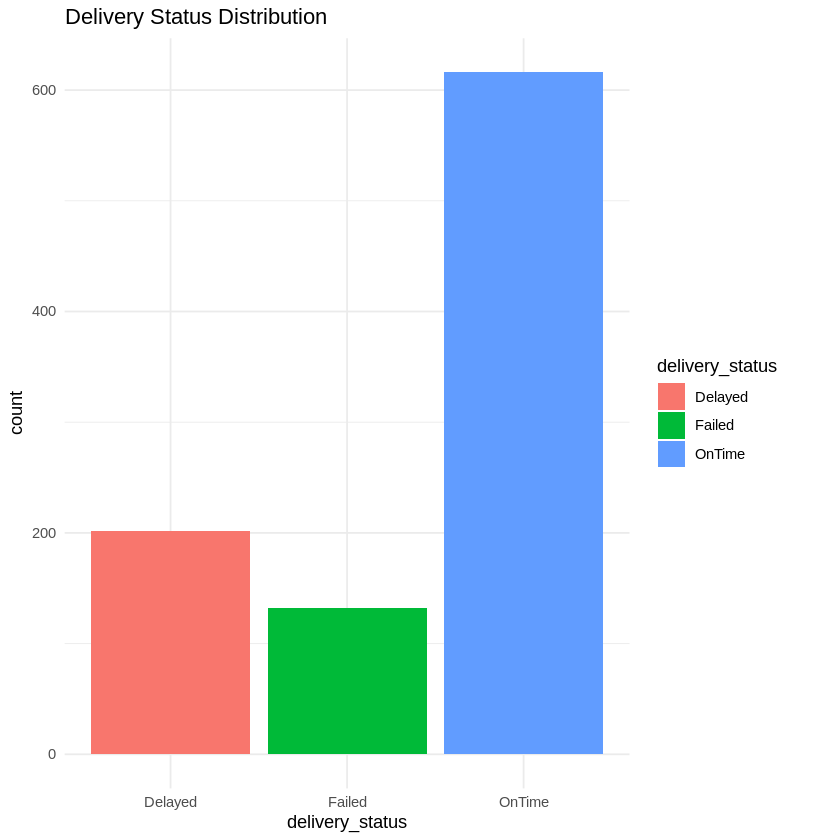

In [43]:
ggplot(deliveries, aes(x=delivery_status, fill=delivery_status)) +
  geom_bar() +
  theme_minimal() +
  labs(title="Delivery Status Distribution")

cat("Insight: High failures indicate inefficiency\n")

 Insight: Certain hubs underperform


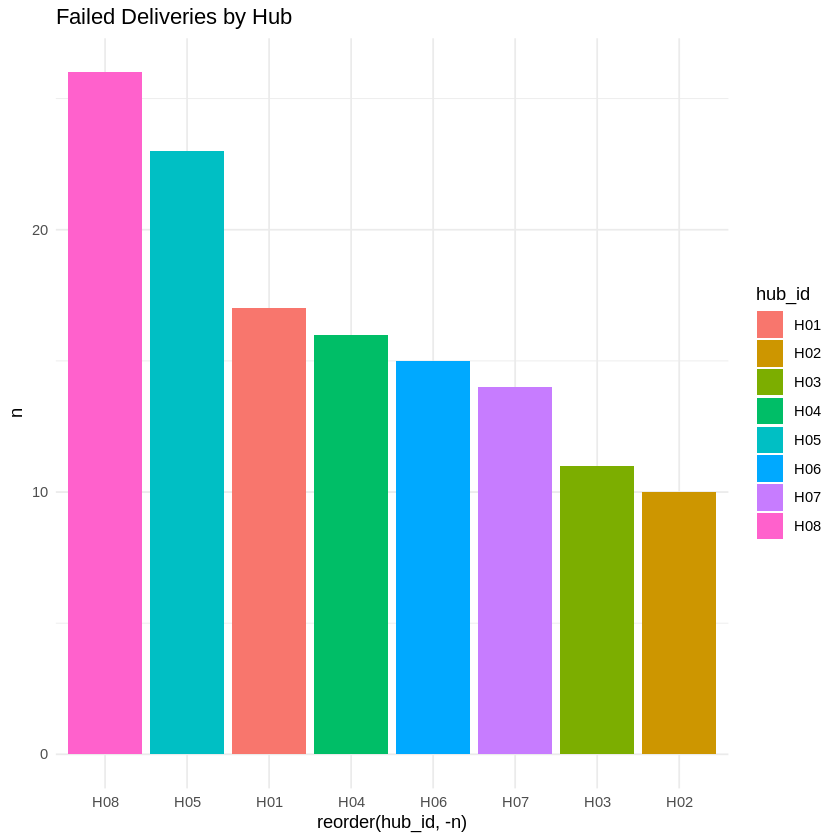

In [44]:
deliveries %>%
  filter(delivery_status == "Failed") %>%
  count(hub_id) %>%
  ggplot(aes(x=reorder(hub_id, -n), y=n, fill=hub_id)) +
  geom_bar(stat="identity") +
  theme_minimal() +
  labs(title="Failed Deliveries by Hub")

cat(" Insight: Certain hubs underperform\n")

Insight: Identifies most frequent complaint types


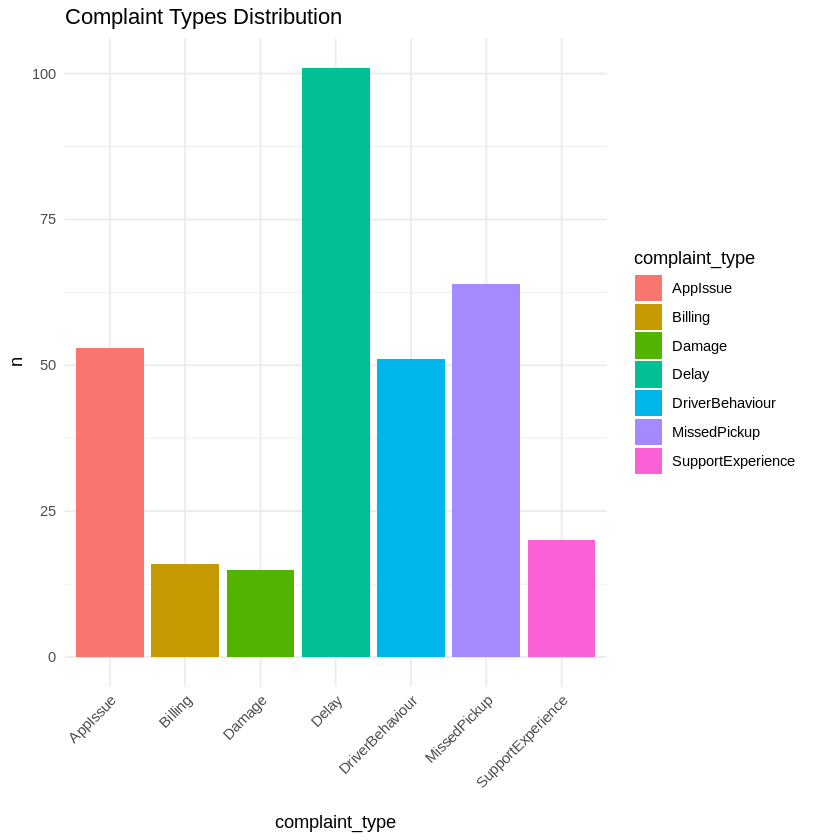

In [45]:
complaints %>%
  count(complaint_type) %>%
  ggplot(aes(x=complaint_type, y=n, fill=complaint_type)) +
  geom_bar(stat="identity") +
  theme_minimal() +
  labs(title="Complaint Types Distribution") +
  theme(axis.text.x = element_text(angle=45, hjust=1))

cat("Insight: Identifies most frequent complaint types\n")

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Insight: Failures reduce customer satisfaction


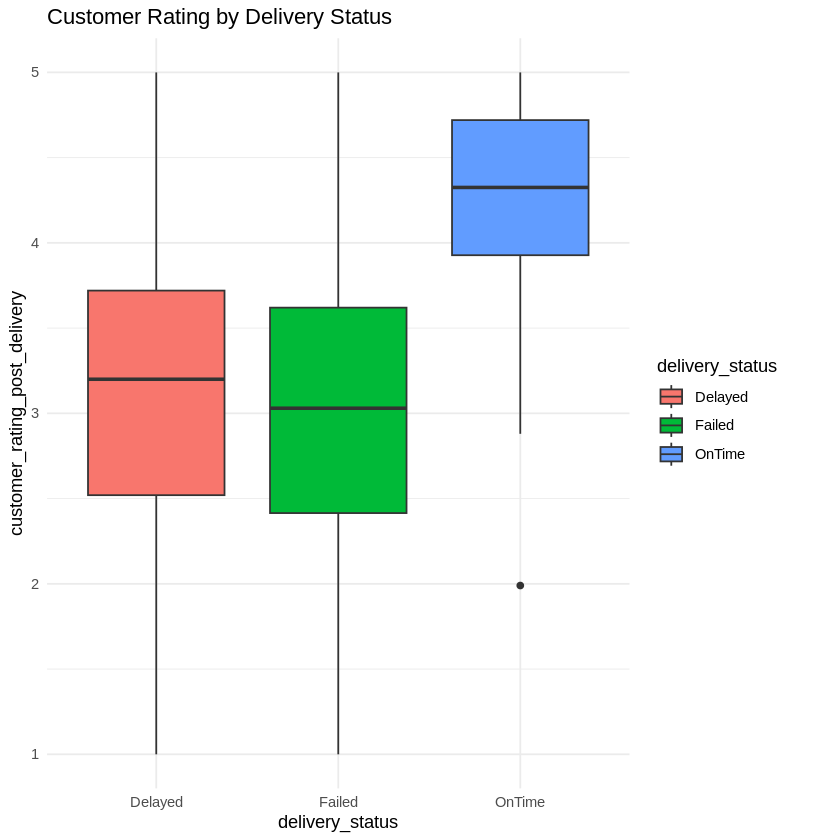

In [46]:
ggplot(deliveries, aes(x=delivery_status, y=customer_rating_post_delivery, fill=delivery_status)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title="Customer Rating by Delivery Status")

cat("Insight: Failures reduce customer satisfaction\n")

Insight: Some zones have higher fuel cost → route inefficiency


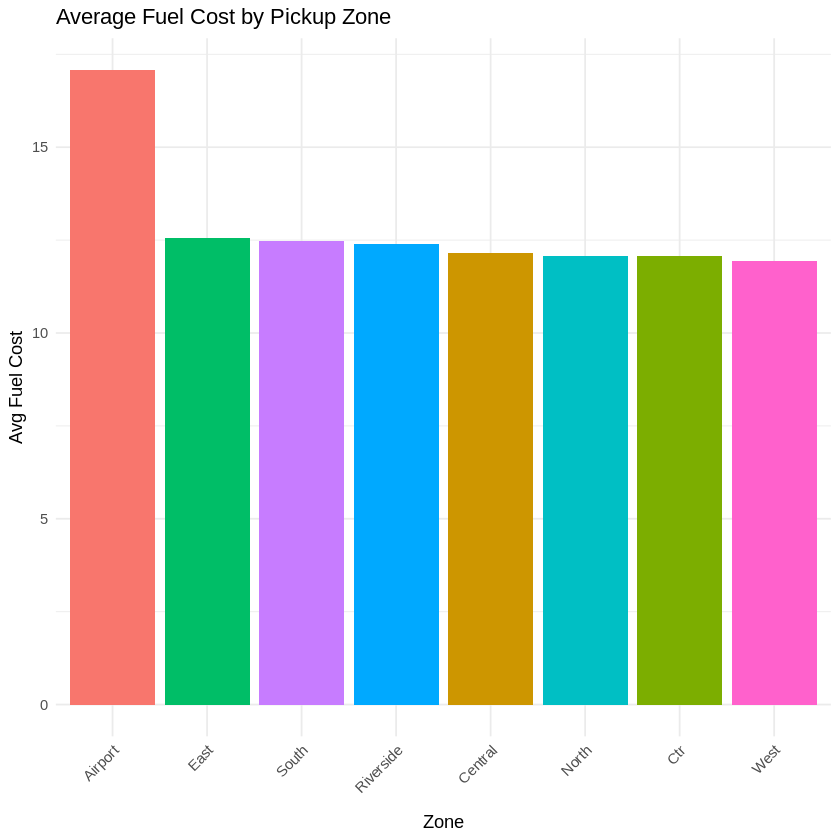

In [47]:
# R VISUALISATION - Fuel Cost by Zone

merged_r <- merge(deliveries, orders, by="order_id")

library(dplyr)
library(ggplot2)

merged_r %>%
  group_by(pickup_zone) %>%
  summarise(avg_cost = mean(fuel_or_charge_cost)) %>%
  ggplot(aes(x=reorder(pickup_zone, -avg_cost),
             y=avg_cost, fill=pickup_zone)) +
  geom_bar(stat="identity") +
  theme_minimal() +
  labs(title="Average Fuel Cost by Pickup Zone",
       x="Zone", y="Avg Fuel Cost") +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

cat("Insight: Some zones have higher fuel cost → route inefficiency\n")

## Limitations of Relational Systems

While SQL is highly effective for analysing structured data, it has several limitations:

- It struggles to handle nested and semi-structured data
- It is not well suited for real-time or event-driven data
- It makes integration of app logs and user interaction data complex

These limitations highlight the need for a more flexible data model.



## Conclusion

The SQL analysis reveals that:

- Delivery failures are concentrated in specific hubs
- Failed deliveries lead to higher operational costs
- Customer complaints are closely linked to service failures
- Route inefficiencies contribute to poor performance

However, relational databases alone cannot efficiently handle complex,
event-driven, and semi-structured data.

Therefore, a NoSQL approach (explored in the next section) is required
to overcome these limitations and support scalable analytics.